# ARTI404 - Lab 2: Image Processing
## Digital Image Fundamentals

**Objectives:**
1. Understand Sampling and Quantization
2. Apply Arithmetic Operations on Images
3. Apply Logical Operations on Images

---

## 📦 Import Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Display settings
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 12

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 🔧 Helper Functions

In [2]:
def sample_image(image, factor):
    """
    Downsamples the image by the given factor.
    Args:
        image (numpy array): Original image.
        factor (int): Factor by which to downsample.
    Returns:
        numpy array: Downsampled image.
    """
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor), 
                               interpolation=cv2.INTER_NEAREST)
    return sampled_image

def quantize_image(image, levels):
    """
    Reduces the number of grayscale levels in the image.
    Args:
        image (numpy array): Original image.
        levels (int): Number of grayscale levels.
    Returns:
        numpy array: Quantized image.
    """
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image

def plot_images(original, sampled, quantized):
    """
    Plots the original, sampled, and quantized images side by side.
    """
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

print('✅ Helper functions defined')

✅ Helper functions defined


## 🖼️ Load Image

**Note:** If the original image is not available, a test image will be created automatically

⚠️  Original image not found, creating test image...
✅ Test image created


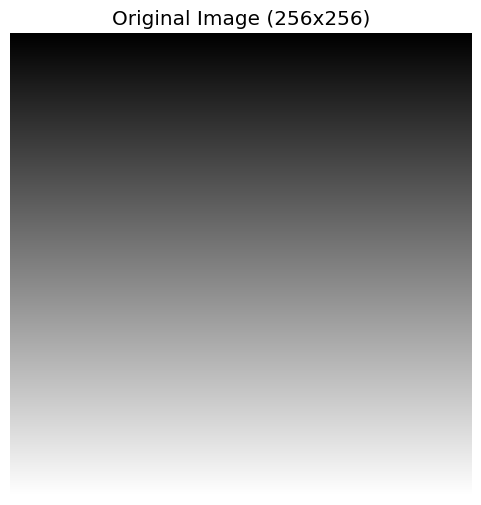

Image shape: (256, 256)
Data type: uint8
Value range: [0, 255]


In [3]:
# Attempt to load the original image
image_path = '../images/lena_gray_256.tif'

try:
    original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if original_image is None:
        raise FileNotFoundError
    print('✅ Original image loaded successfully')
except:
    print('⚠️  Original image not found, creating test image...')
    # Create test image - gradient
    original_image = np.zeros((256, 256), dtype=np.uint8)
    for i in range(256):
        original_image[i, :] = i
    print('✅ Test image created')

# Display original image
plt.figure(figsize=(6, 6))
plt.imshow(original_image, cmap='gray')
plt.title(f'Original Image ({original_image.shape[0]}x{original_image.shape[1]})')
plt.axis('off')
plt.show()

print(f'Image shape: {original_image.shape}')
print(f'Data type: {original_image.dtype}')
print(f'Value range: [{original_image.min()}, {original_image.max()}]')

---
# 📌 Task #1: Sampling and Quantization

## Objective:
Change the sampling and quantization parameters and observe the effects

## 1.1 Test Different Sampling Factors

Sampling Factor 2: (256, 256) → (128, 128)
Sampling Factor 4: (256, 256) → (64, 64)
Sampling Factor 8: (256, 256) → (32, 32)
Sampling Factor 16: (256, 256) → (16, 16)


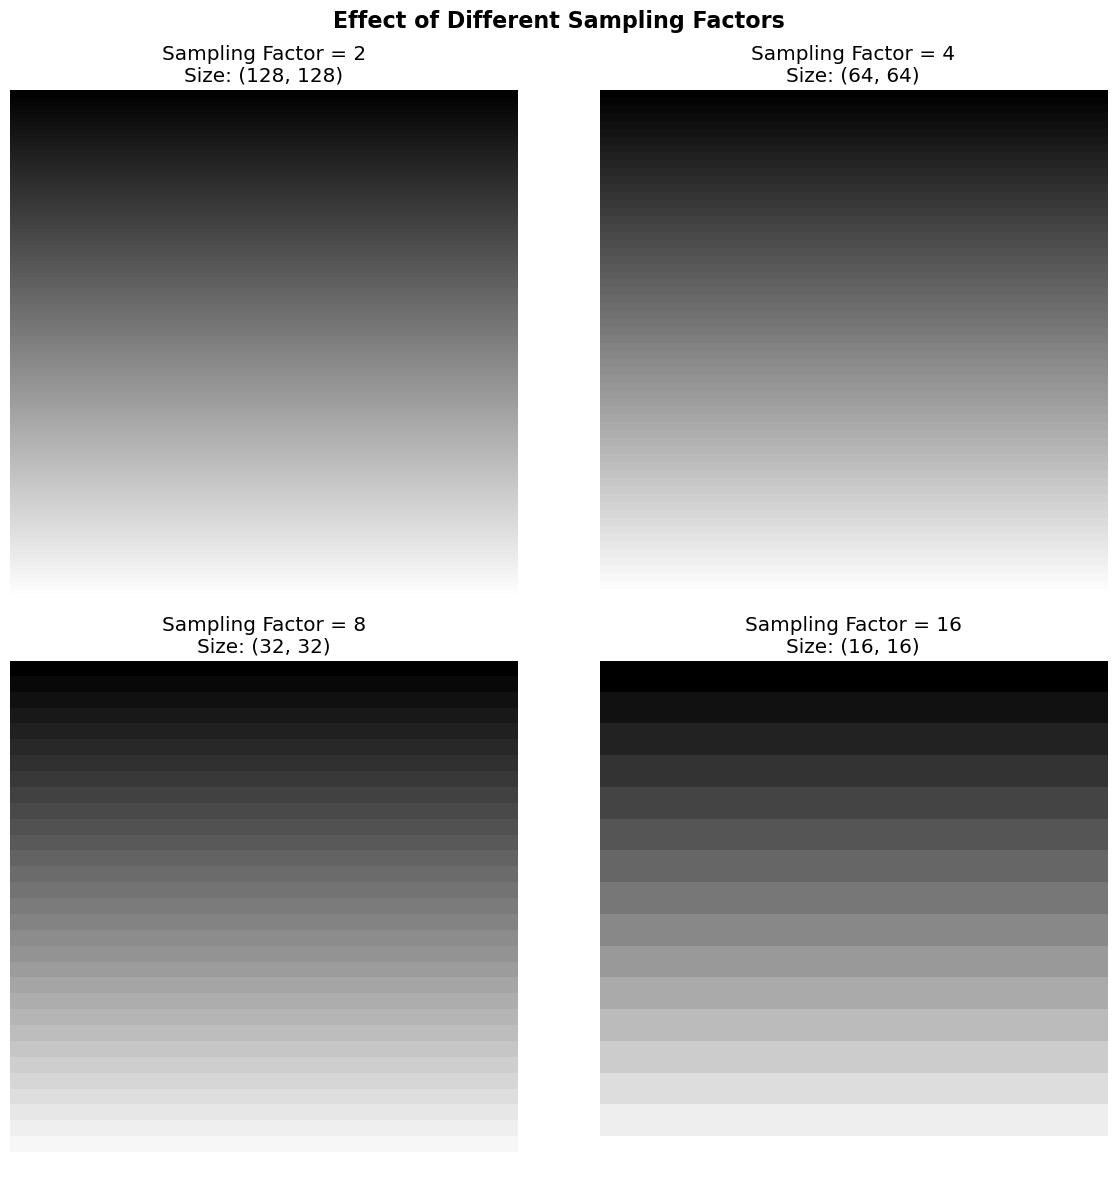

In [4]:
# Test different sampling factors
sampling_factors = [2, 4, 8, 16]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Effect of Different Sampling Factors', fontsize=16, fontweight='bold')

for idx, factor in enumerate(sampling_factors):
    sampled = sample_image(original_image, factor)
    ax = axes[idx // 2, idx % 2]
    ax.imshow(sampled, cmap='gray')
    ax.set_title(f'Sampling Factor = {factor}\nSize: {sampled.shape}')
    ax.axis('off')
    print(f'Sampling Factor {factor}: {original_image.shape} → {sampled.shape}')

plt.tight_layout()
plt.show()

### 📊 Observations:
- Higher sampling factor reduces image size
- Fine details are lost with increasing factor

## 1.2 Test Different Quantization Levels

Quantization 128 levels: 128 unique values
Quantization 64 levels: 64 unique values
Quantization 32 levels: 32 unique values
Quantization 16 levels: 16 unique values
Quantization 8 levels: 8 unique values
Quantization 4 levels: 4 unique values
Quantization 2 levels: 2 unique values


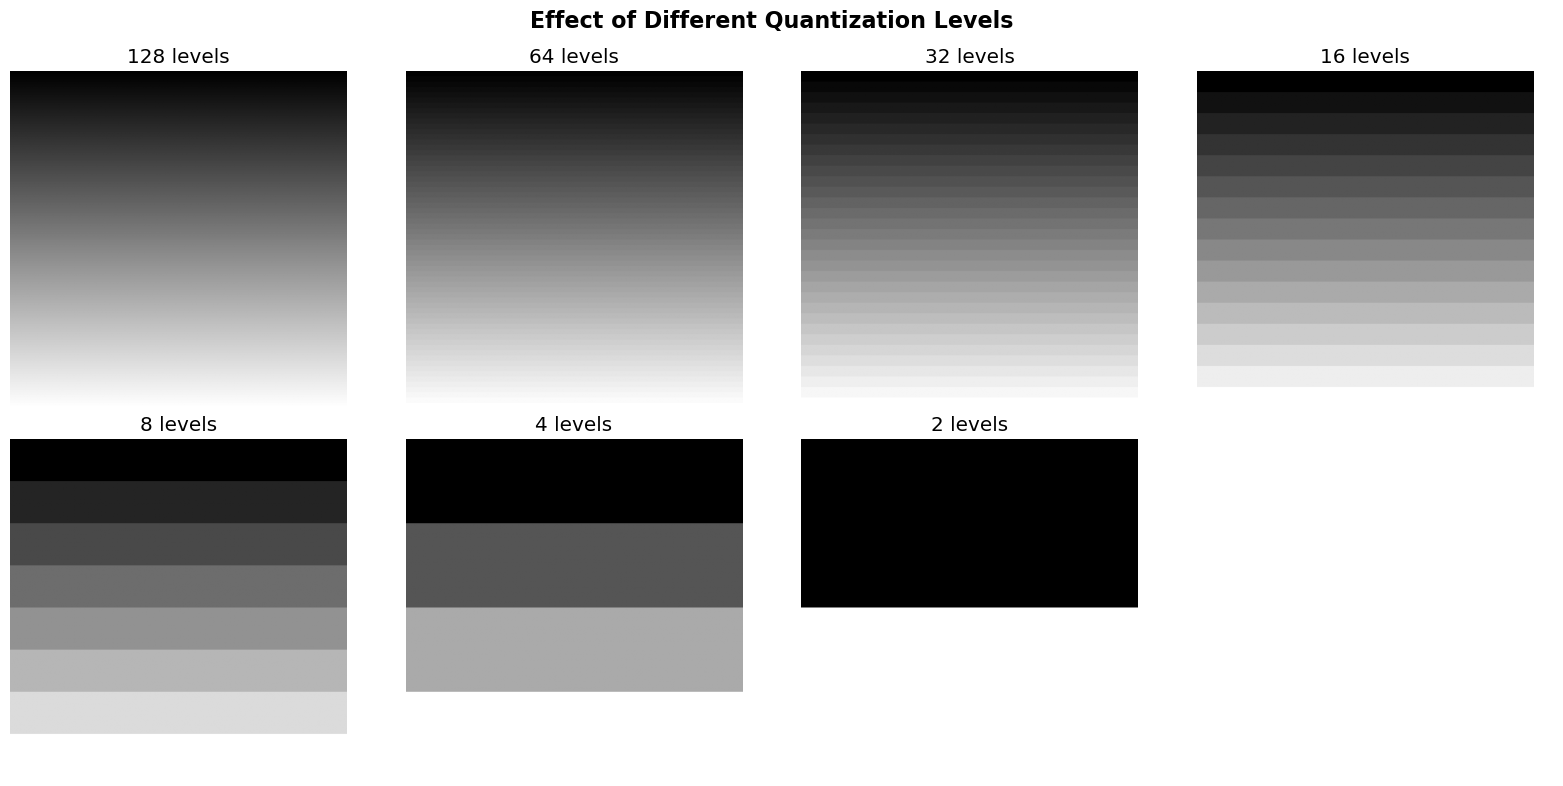

In [5]:
# Test different quantization levels
quantization_levels = [128, 64, 32, 16, 8, 4, 2]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Effect of Different Quantization Levels', fontsize=16, fontweight='bold')

for idx, levels in enumerate(quantization_levels):
    quantized = quantize_image(original_image, levels)
    ax = axes[idx // 4, idx % 4]
    ax.imshow(quantized, cmap='gray')
    ax.set_title(f'{levels} levels')
    ax.axis('off')
    unique_values = len(np.unique(quantized))
    print(f'Quantization {levels} levels: {unique_values} unique values')

# Hide last axis
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()

### 📊 Observations:
- Lower quantization levels create visible banding
- At 2 levels, image becomes binary (black and white only)

## 1.3 Combine Sampling and Quantization

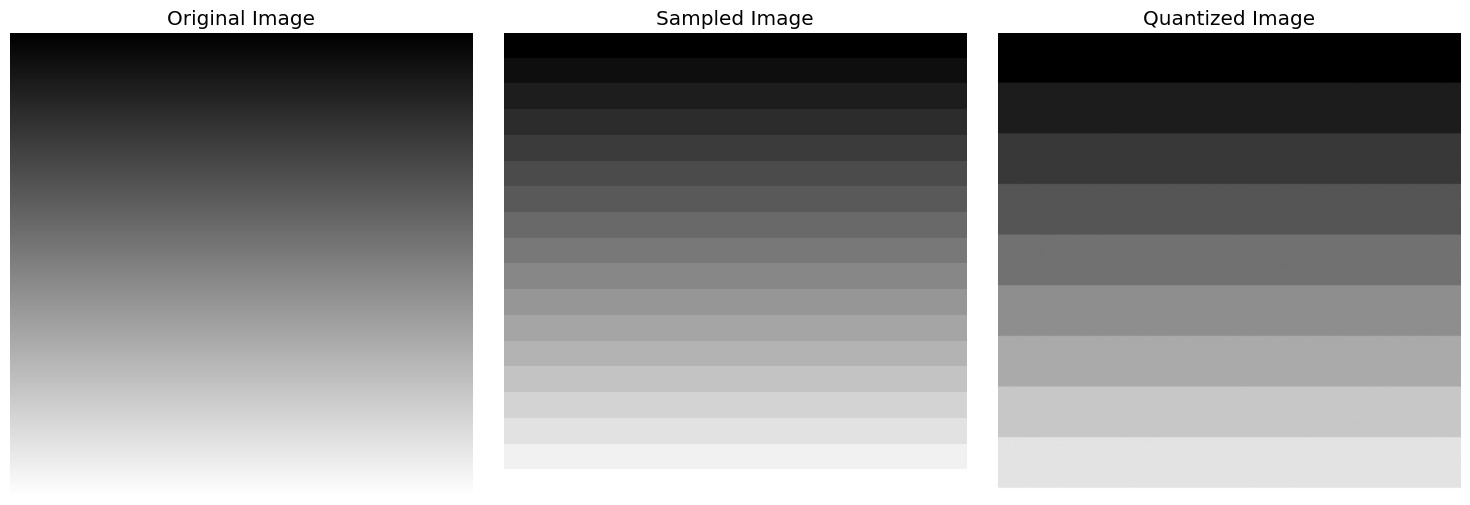

Original image: (256, 256)
Sampled (factor=14): (18, 18)
Quantized (levels=9): 10 unique values


In [6]:
# Test combination of sampling and quantization
sampling_factor = 14  # From original example
quantization_levels = 9  # From original example

# Apply operations
sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

# Display results
plot_images(original_image, sampled_image, quantized_image)

print(f'Original image: {original_image.shape}')
print(f'Sampled (factor={sampling_factor}): {sampled_image.shape}')
print(f'Quantized (levels={quantization_levels}): {len(np.unique(quantized_image))} unique values')

## 1.4 Custom Values (Optional)

**Try your own values!** Change the values and run the cell:

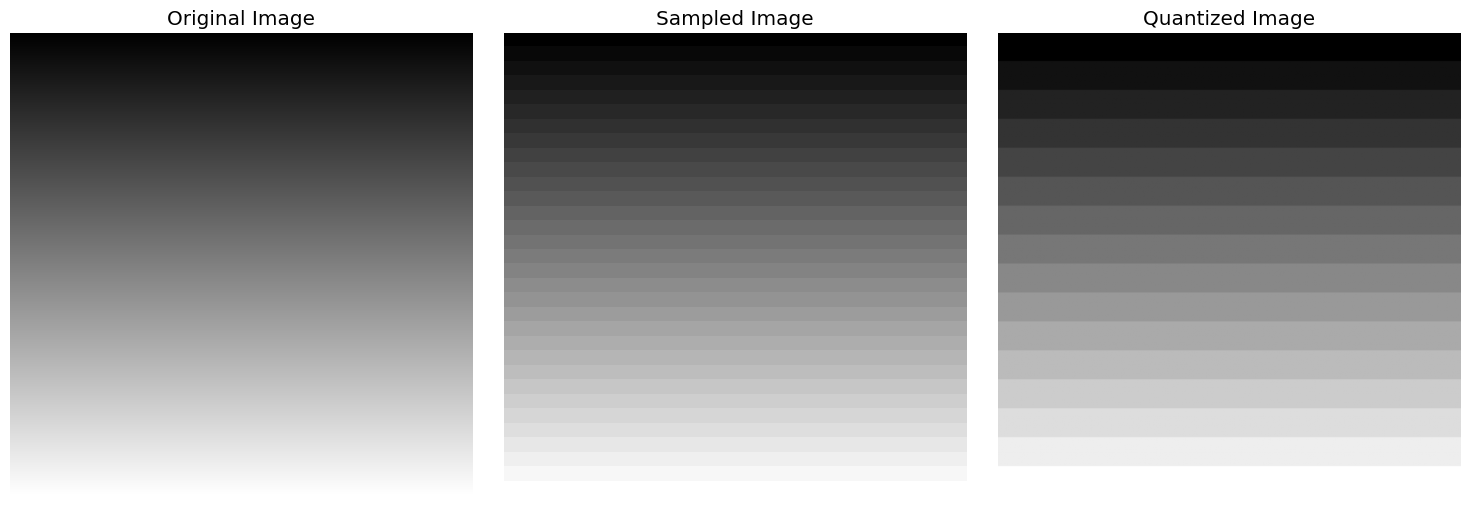

✨ Custom test:
Sampling factor: 8 → new size: (32, 32)
Quantization levels: 16 → unique values: 16


In [7]:
# 🎯 Change values here
my_sampling_factor = 8
my_quantization_levels = 16

# Apply
my_sampled = sample_image(original_image, my_sampling_factor)
my_quantized = quantize_image(original_image, my_quantization_levels)

# Display
plot_images(original_image, my_sampled, my_quantized)

print(f'✨ Custom test:')
print(f'Sampling factor: {my_sampling_factor} → new size: {my_sampled.shape}')
print(f'Quantization levels: {my_quantization_levels} → unique values: {len(np.unique(my_quantized))}')

---
# 📌 Task #2: Arithmetic and Logical Operations

## Objectives:
1. Subtract two images
2. Add constant value (175)
3. Set Difference
4. Symmetric Difference
5. Intersection

## 2.0 Prepare Images

⚠️  Creating test images...
✅ Test images created


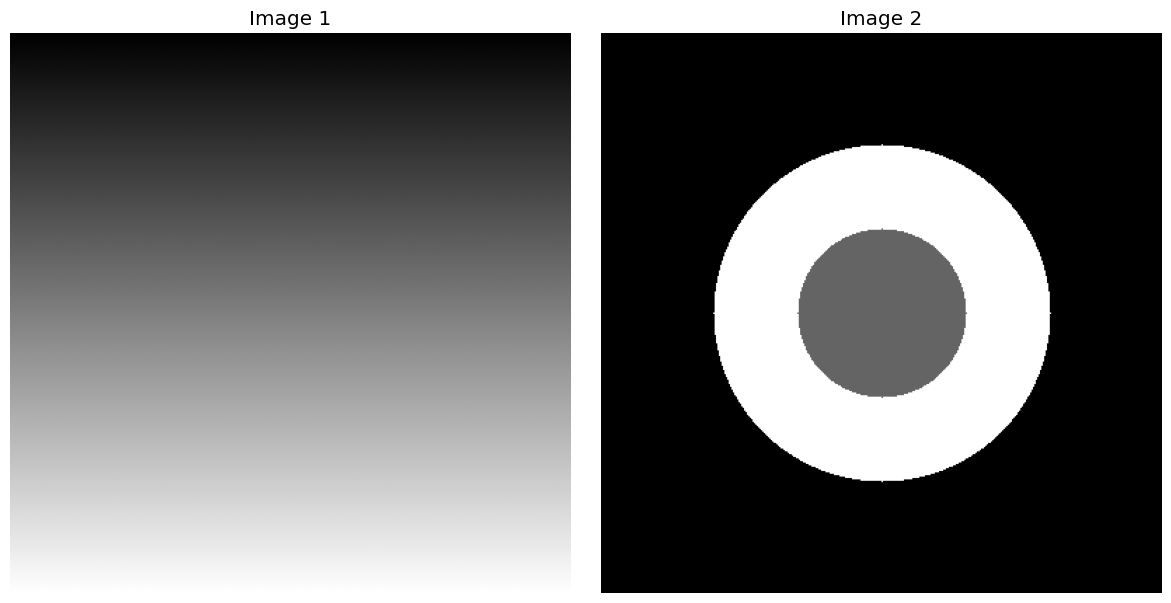

Image 1 shape: (400, 400), range: [0, 254]
Image 2 shape: (400, 400), range: [0, 255]


In [8]:
# Attempt to load original images
try:
    img1 = Image.open('../images/lena_gray_256.tif')
    img2 = Image.open('../images/cameraman.tif')
    
    resize = (400, 400)
    img1 = img1.resize(resize, Image.Resampling.LANCZOS)
    img2 = img2.resize(resize, Image.Resampling.LANCZOS)
    
    im1arr = np.asarray(img1)
    im2arr = np.asarray(img2)
    
    print('✅ Original images loaded successfully')
    
except:
    print('⚠️  Creating test images...')
    
    # Image 1: Gradient
    im1arr = np.zeros((400, 400), dtype=np.uint8)
    for i in range(400):
        im1arr[i, :] = int(255 * i / 400)
    
    # Image 2: Circles
    im2arr = np.zeros((400, 400), dtype=np.uint8)
    cv2.circle(im2arr, (200, 200), 120, 255, -1)
    cv2.circle(im2arr, (200, 200), 60, 100, -1)
    
    print('✅ Test images created')

# Display both images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(im1arr, cmap='gray')
axes[0].set_title('Image 1')
axes[0].axis('off')

axes[1].imshow(im2arr, cmap='gray')
axes[1].set_title('Image 2')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f'Image 1 shape: {im1arr.shape}, range: [{im1arr.min()}, {im1arr.max()}]')
print(f'Image 2 shape: {im2arr.shape}, range: [{im2arr.min()}, {im2arr.max()}]')

## 2.1 Subtraction (Subtract Two Images)

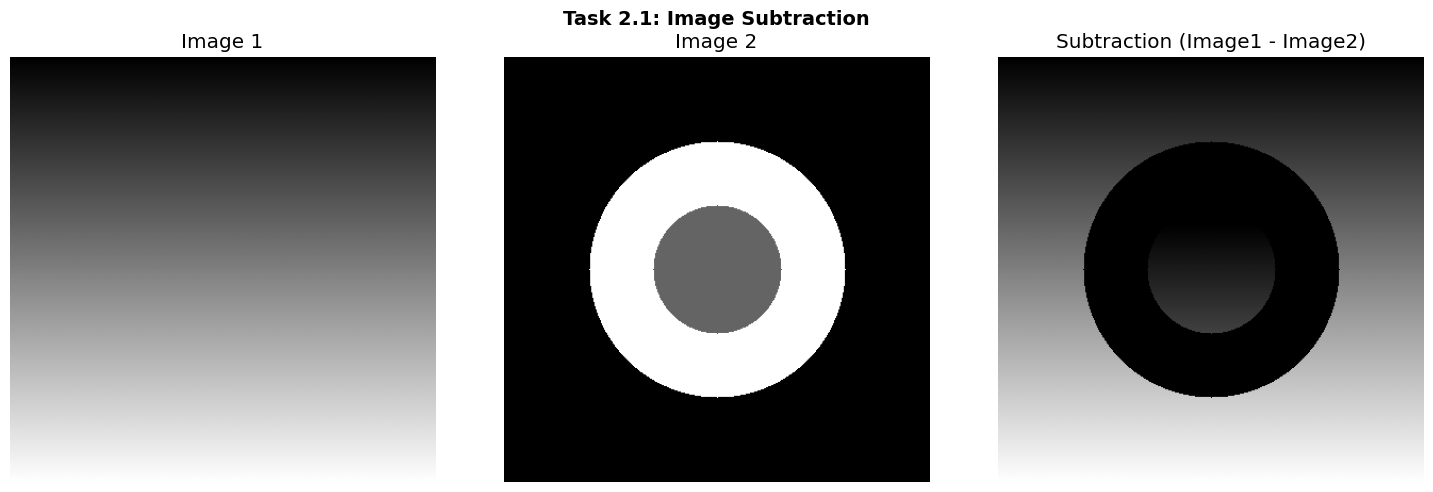

✅ Task 2.1 Complete
Result value range: [0, 254]
Mean value: 92.72


In [9]:
# Subtract images
subtraction = cv2.subtract(im1arr, im2arr)

# Display result
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(im1arr, cmap='gray')
axes[0].set_title('Image 1')
axes[0].axis('off')

axes[1].imshow(im2arr, cmap='gray')
axes[1].set_title('Image 2')
axes[1].axis('off')

axes[2].imshow(subtraction, cmap='gray')
axes[2].set_title('Subtraction (Image1 - Image2)')
axes[2].axis('off')

plt.suptitle('Task 2.1: Image Subtraction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'✅ Task 2.1 Complete')
print(f'Result value range: [{subtraction.min()}, {subtraction.max()}]')
print(f'Mean value: {subtraction.mean():.2f}')

## 2.2 Add Constant (Add Constant Value)

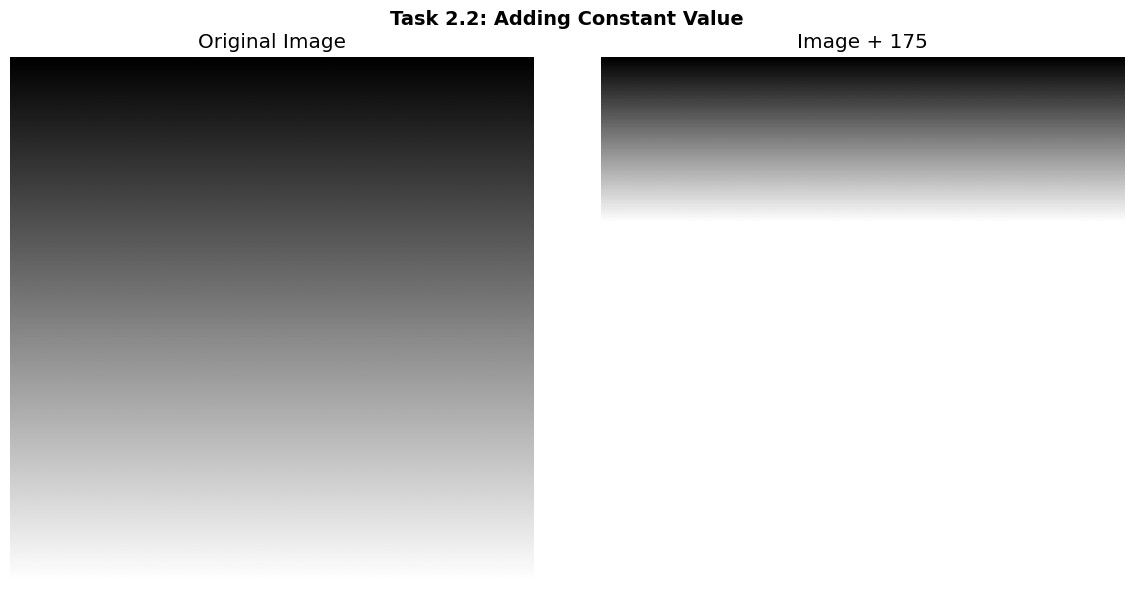

✅ Task 2.2 Complete
Original - mean: 126.69
After addition - mean: 242.20
Difference: 115.51


In [10]:
# Add constant value
constant_value = 175
addition_constant = cv2.add(im1arr, constant_value)

# Display result
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(im1arr, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(addition_constant, cmap='gray')
axes[1].set_title(f'Image + {constant_value}')
axes[1].axis('off')

plt.suptitle('Task 2.2: Adding Constant Value', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'✅ Task 2.2 Complete')
print(f'Original - mean: {im1arr.mean():.2f}')
print(f'After addition - mean: {addition_constant.mean():.2f}')
print(f'Difference: {addition_constant.mean() - im1arr.mean():.2f}')

## 2.3 Set Difference (A - B)

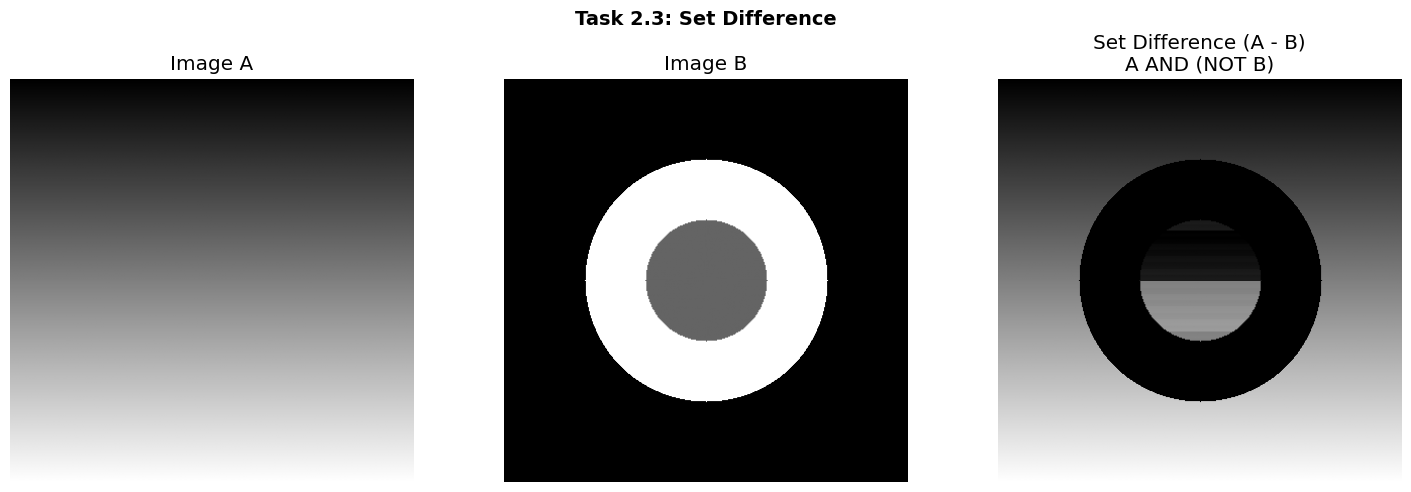

✅ Task 2.3 Complete
Non-zero pixels: 124954


In [11]:
# Set Difference: A AND (NOT B)
set_difference = cv2.bitwise_and(im1arr, cv2.bitwise_not(im2arr))

# Display result
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(im1arr, cmap='gray')
axes[0].set_title('Image A')
axes[0].axis('off')

axes[1].imshow(im2arr, cmap='gray')
axes[1].set_title('Image B')
axes[1].axis('off')

axes[2].imshow(set_difference, cmap='gray')
axes[2].set_title('Set Difference (A - B)\nA AND (NOT B)')
axes[2].axis('off')

plt.suptitle('Task 2.3: Set Difference', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'✅ Task 2.3 Complete')
print(f'Non-zero pixels: {np.count_nonzero(set_difference)}')

## 2.4 Symmetric Difference (A XOR B)

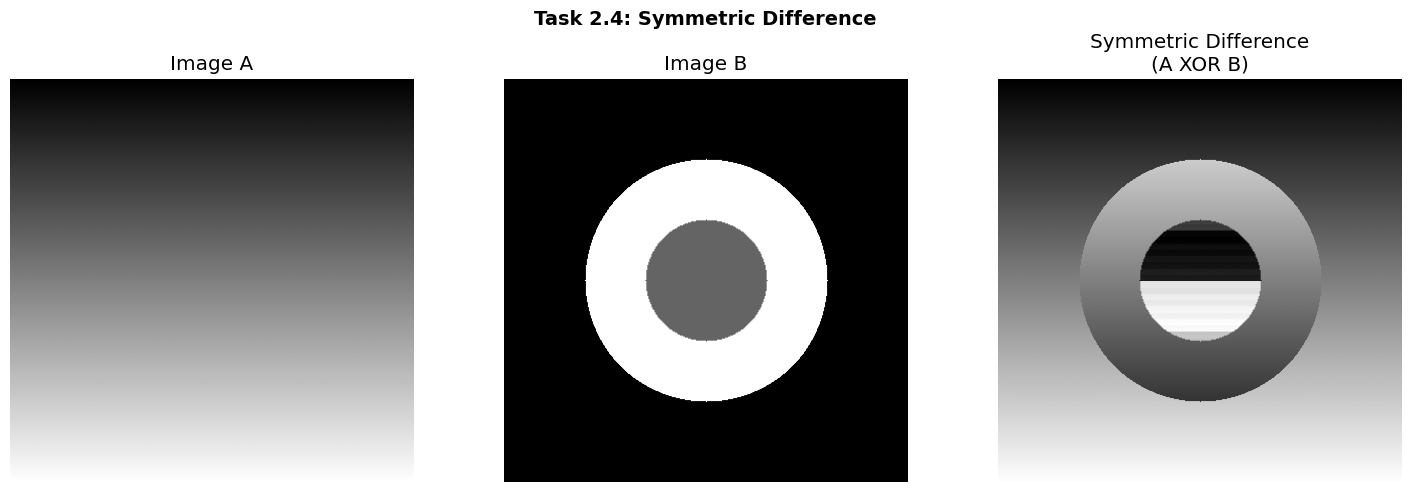

✅ Task 2.4 Complete
Different pixels: 159032


In [12]:
# Symmetric Difference: A XOR B
symmetric_difference = cv2.bitwise_xor(im1arr, im2arr)

# Display result
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(im1arr, cmap='gray')
axes[0].set_title('Image A')
axes[0].axis('off')

axes[1].imshow(im2arr, cmap='gray')
axes[1].set_title('Image B')
axes[1].axis('off')

axes[2].imshow(symmetric_difference, cmap='gray')
axes[2].set_title('Symmetric Difference\n(A XOR B)')
axes[2].axis('off')

plt.suptitle('Task 2.4: Symmetric Difference', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'✅ Task 2.4 Complete')
print(f'Different pixels: {np.count_nonzero(symmetric_difference)}')

## 2.5 Intersection (A AND B)

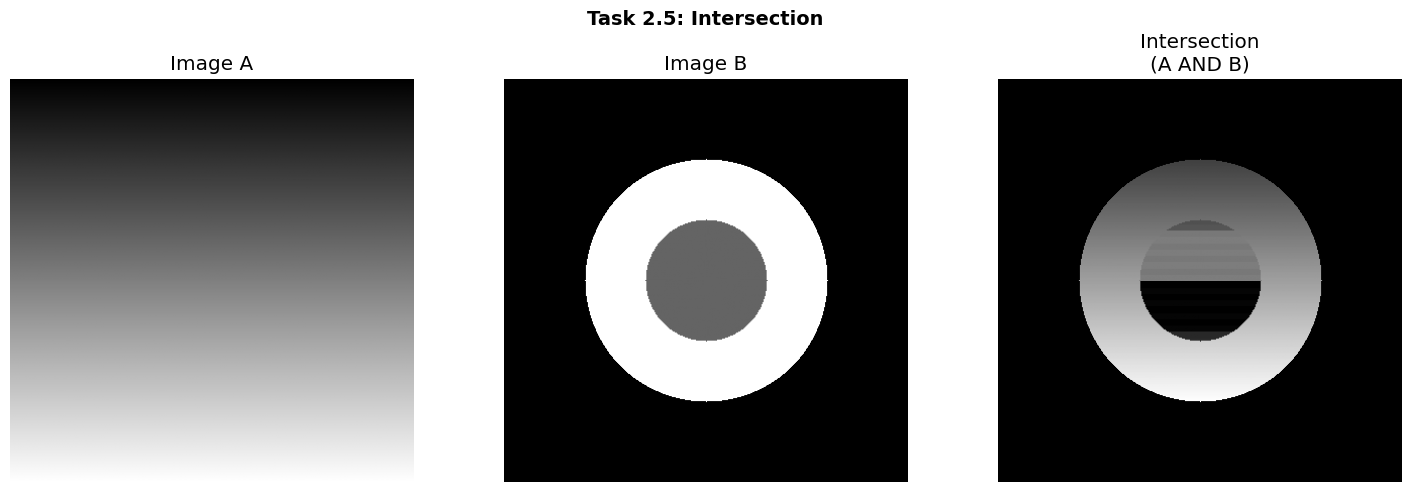

✅ Task 2.5 Complete
Common pixels: 42449


In [13]:
# Intersection: A AND B
intersection = cv2.bitwise_and(im1arr, im2arr)

# Display result
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(im1arr, cmap='gray')
axes[0].set_title('Image A')
axes[0].axis('off')

axes[1].imshow(im2arr, cmap='gray')
axes[1].set_title('Image B')
axes[1].axis('off')

axes[2].imshow(intersection, cmap='gray')
axes[2].set_title('Intersection\n(A AND B)')
axes[2].axis('off')

plt.suptitle('Task 2.5: Intersection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'✅ Task 2.5 Complete')
print(f'Common pixels: {np.count_nonzero(intersection)}')

## 2.6 Summary of All Operations

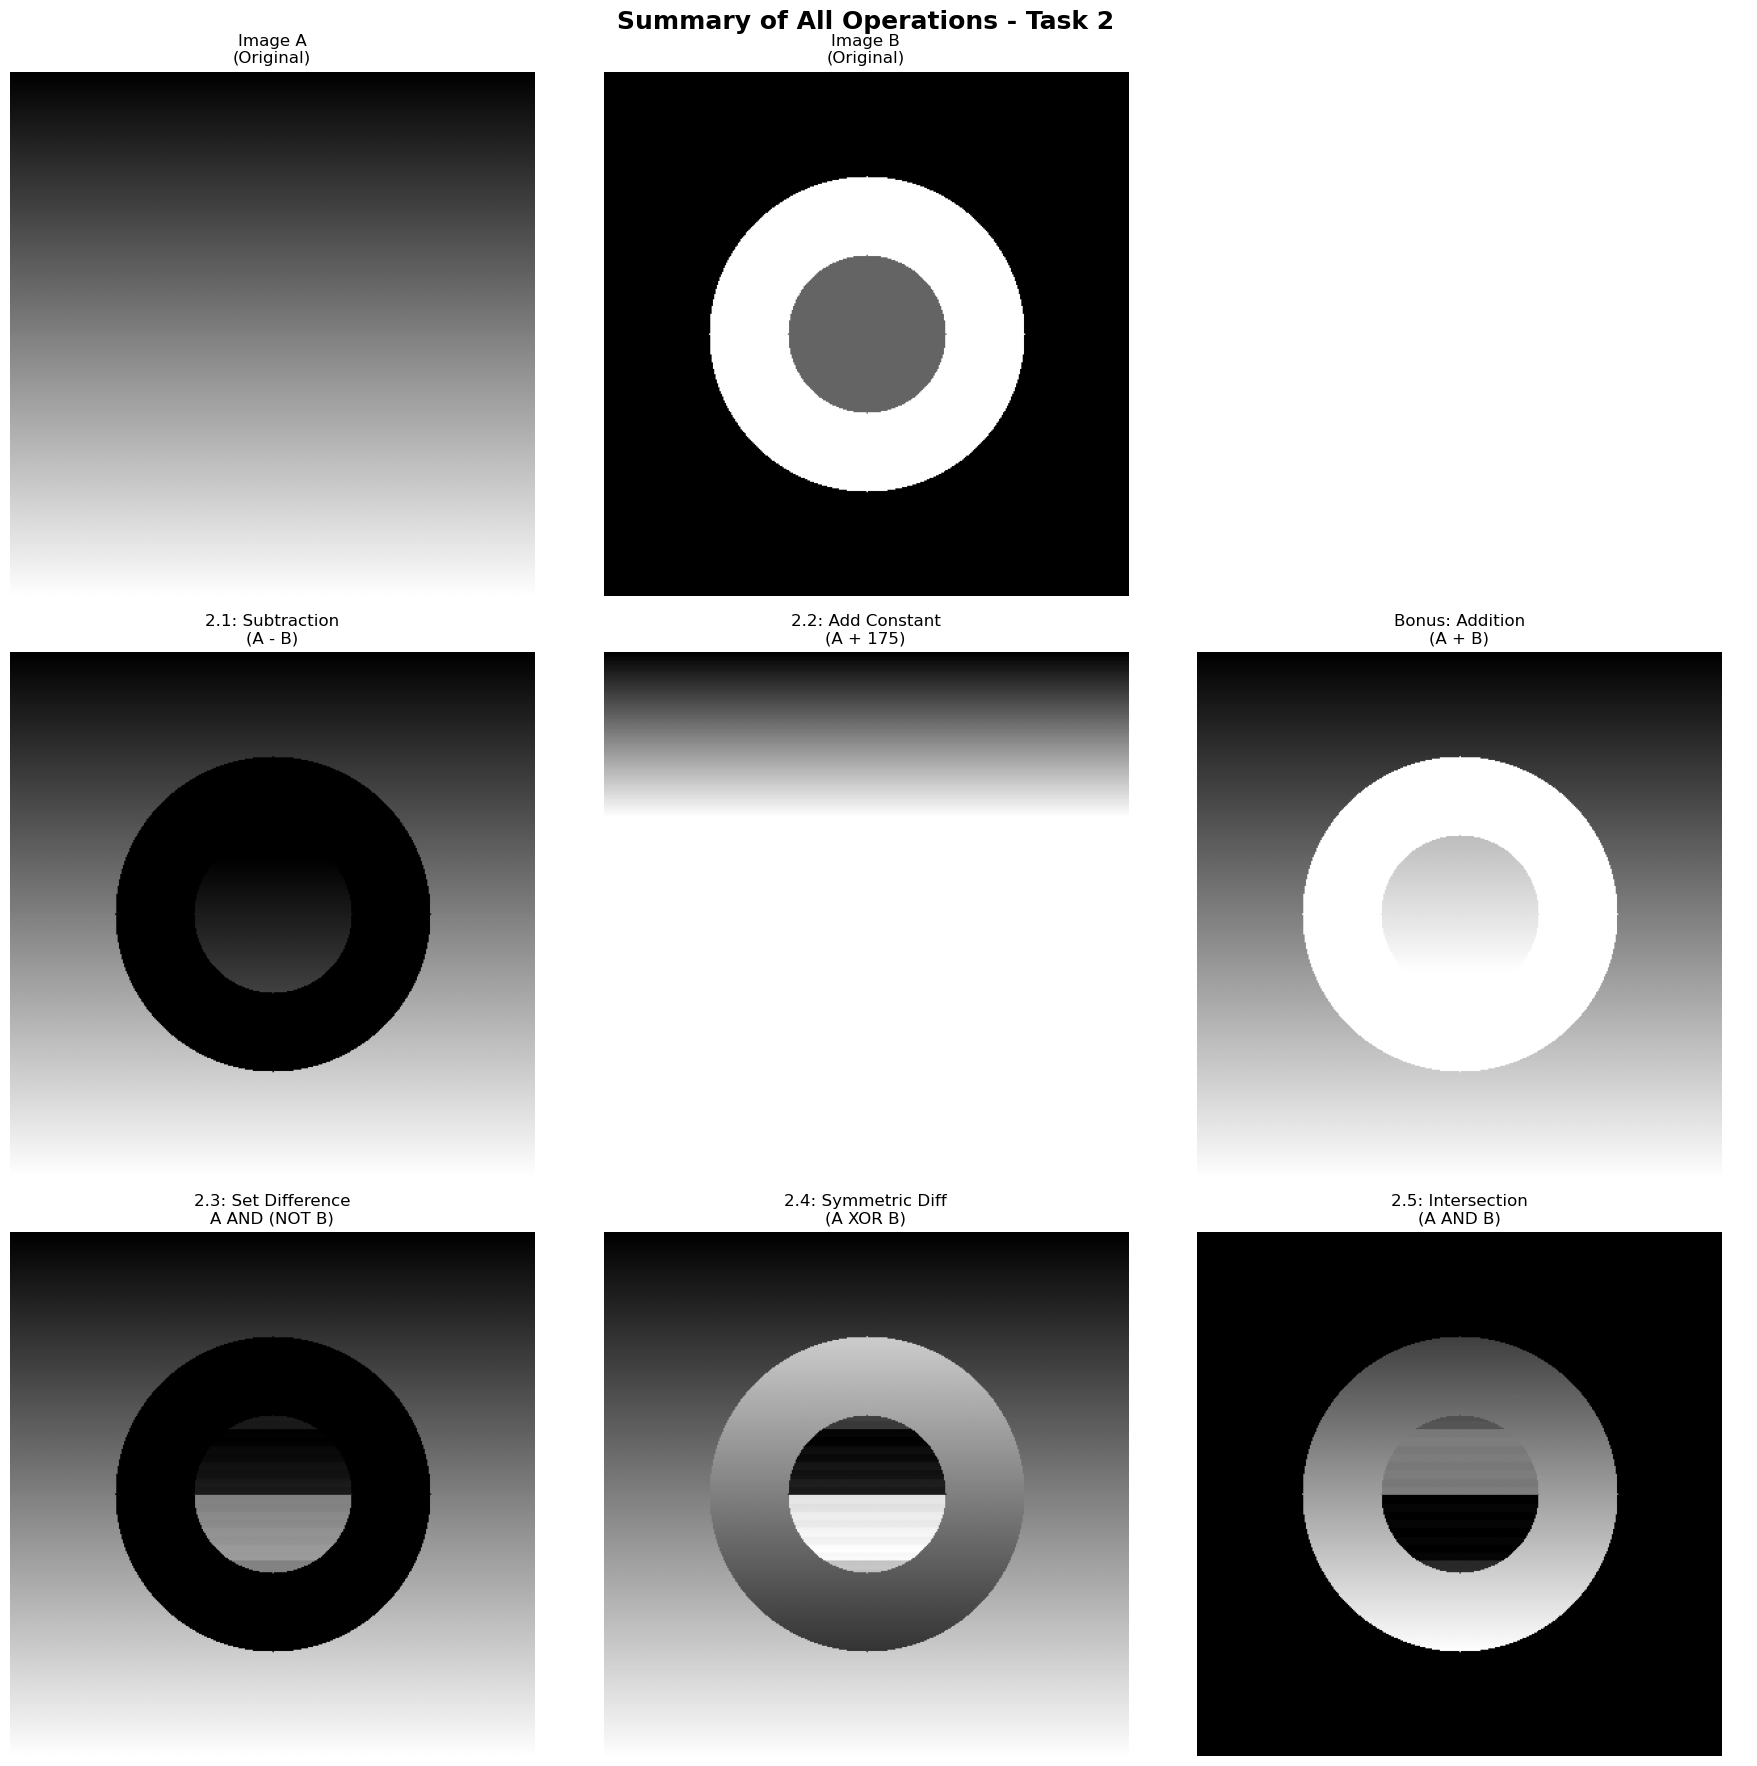

In [14]:
# Display all results in one view
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
fig.suptitle('Summary of All Operations - Task 2', fontsize=18, fontweight='bold')

# Row 1: Original images
axes[0, 0].imshow(im1arr, cmap='gray')
axes[0, 0].set_title('Image A\n(Original)', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(im2arr, cmap='gray')
axes[0, 1].set_title('Image B\n(Original)', fontsize=12)
axes[0, 1].axis('off')

axes[0, 2].axis('off')  # Empty

# Row 2: Arithmetic operations
axes[1, 0].imshow(subtraction, cmap='gray')
axes[1, 0].set_title('2.1: Subtraction\n(A - B)', fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(addition_constant, cmap='gray')
axes[1, 1].set_title('2.2: Add Constant\n(A + 175)', fontsize=12)
axes[1, 1].axis('off')

axes[1, 2].imshow(cv2.add(im1arr, im2arr), cmap='gray')
axes[1, 2].set_title('Bonus: Addition\n(A + B)', fontsize=12)
axes[1, 2].axis('off')

# Row 3: Logical operations
axes[2, 0].imshow(set_difference, cmap='gray')
axes[2, 0].set_title('2.3: Set Difference\nA AND (NOT B)', fontsize=12)
axes[2, 0].axis('off')

axes[2, 1].imshow(symmetric_difference, cmap='gray')
axes[2, 1].set_title('2.4: Symmetric Diff\n(A XOR B)', fontsize=12)
axes[2, 1].axis('off')

axes[2, 2].imshow(intersection, cmap='gray')
axes[2, 2].set_title('2.5: Intersection\n(A AND B)', fontsize=12)
axes[2, 2].axis('off')

plt.tight_layout()
plt.show()

---
## 📊 Statistical Analysis of Results

In [15]:
import pandas as pd

# Results comparison table
results = {
    'Operation': [
        'Original A',
        'Original B',
        'Subtraction (A-B)',
        'Add Constant (+175)',
        'Set Difference',
        'Symmetric Difference',
        'Intersection'
    ],
    'Min': [
        im1arr.min(),
        im2arr.min(),
        subtraction.min(),
        addition_constant.min(),
        set_difference.min(),
        symmetric_difference.min(),
        intersection.min()
    ],
    'Max': [
        im1arr.max(),
        im2arr.max(),
        subtraction.max(),
        addition_constant.max(),
        set_difference.max(),
        symmetric_difference.max(),
        intersection.max()
    ],
    'Mean': [
        im1arr.mean(),
        im2arr.mean(),
        subtraction.mean(),
        addition_constant.mean(),
        set_difference.mean(),
        symmetric_difference.mean(),
        intersection.mean()
    ],
    'Non-zero': [
        np.count_nonzero(im1arr),
        np.count_nonzero(im2arr),
        np.count_nonzero(subtraction),
        np.count_nonzero(addition_constant),
        np.count_nonzero(set_difference),
        np.count_nonzero(symmetric_difference),
        np.count_nonzero(intersection)
    ]
}

df = pd.DataFrame(results)
df['Mean'] = df['Mean'].round(2)

print('\n📊 Statistical Results Table:')
print('='*70)
print(df.to_string(index=False))
print('='*70)


📊 Statistical Results Table:
           Operation  Min  Max   Mean  Non-zero
          Original A    0  254 126.69    159200
          Original B    0  255  61.14     45225
   Subtraction (A-B)    0  254  92.72    124163
 Add Constant (+175)  175  255 242.20    160000
      Set Difference    0  254  96.20    124954
Symmetric Difference    0  255 126.85    159032
        Intersection    0  204  30.49     42449
